In [1]:
from fleet_replacement.episode import EpisodeRecord, EpisodeRecorder
from fleet_replacement.envs.fleet_replacement import FleetReplacementEnv
from fleet_replacement.policies import LookaheadAgent
from fleet_replacement.config import load_env_config

config = load_env_config("../configs/env.yaml")
env = EpisodeRecorder(FleetReplacementEnv(config=config))
agent = LookaheadAgent(config)

obs, _ = env.reset(seed=42)
while True:
    obs, reward, terminated, truncated, info = env.step(agent.select_action(obs))
    if terminated or truncated:
        break

record = env.episode_record
df = record.to_dataframe()  # pandas DataFrame, indexed by year
record.save("../results/ep42.pkl")  # persist

# For visualisation:
record.years  # (35,)
record.n_electric  # (35,)
record.actions  # (35, 10)  — heatmap of decisions per slot
record.reward_component("revenue")  # (35,)

c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
c:\git\KTH\fleet-replacement\.venv\Lib\site-packages\linopy\comm

array([27300000.        , 27300000.        , 27300000.        ,
       27300000.        , 27300000.        , 27300000.        ,
       27300000.        , 27300000.        , 27300000.        ,
       27300000.        , 26617500.        , 26080162.90778273,
       24597574.49285075, 24439054.59035627, 24355181.6473808 ,
       24689945.80002162, 24966866.48205417, 25190414.19533994,
       25367346.34642898, 25505206.84491099])

In [2]:
df.head()

,n_electric,n_diesel,avg_age,energy_price_diesel,energy_price_electricity,purchase_price_DT,purchase_price_BET,productivity_BET,reward,revenue,diesel_cost,electricity_cost,salary_cost,interest_cost,depreciation_cost,sale_result,capex,opex,total_reward
year,,,,,,,,,,,,,,,,,,,
2025,0,7,3.000000,18.000000,3.000000,1600000.0,3200000.00,0.700000,12483200.0,27300000.0,9.828000e+06,0.0,2800000.0,268800.0,1920000.0,0.0,2188800.0,1.262800e+07,12483200.0
2026,0,7,4.000000,18.288383,2.875461,1600000.0,2955045.00,0.715743,13477742.0,27300000.0,9.985458e+06,0.0,2800000.0,268800.0,1600000.0,832000.0,1868800.0,1.278546e+07,13477742.0
2027,0,7,3.857143,18.819195,2.657462,1600000.0,2553818.25,0.720793,13187919.0,27300000.0,1.027528e+07,0.0,2800000.0,268800.0,1600000.0,832000.0,1868800.0,1.307528e+07,13187919.0
2028,0,7,3.714286,19.053183,2.621959,1600000.0,2361374.50,0.727274,13060162.0,27300000.0,1.040304e+07,0.0,2800000.0,268800.0,1600000.0,832000.0,1868800.0,1.320304e+07,13060162.0
2029,0,7,3.571429,18.915342,2.713659,1600000.0,2286878.75,0.735463,13135423.0,27300000.0,1.032778e+07,0.0,2800000.0,268800.0,1600000.0,832000.0,1868800.0,1.312778e+07,13135423.0


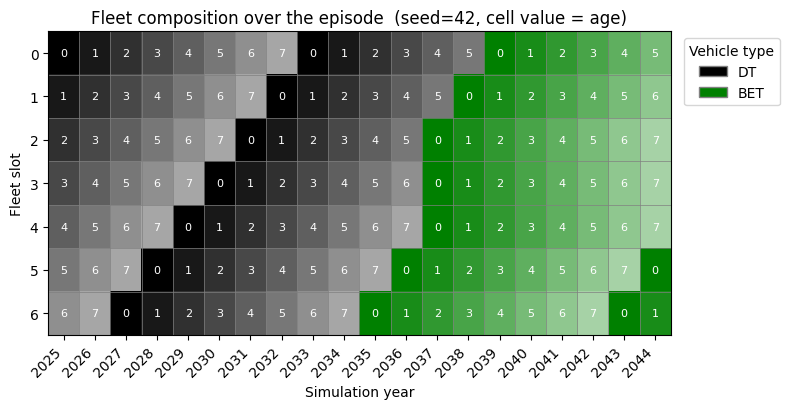

In [3]:
from plot_helpers import plot_episode_fleet_composition

plot_episode_fleet_composition(record)

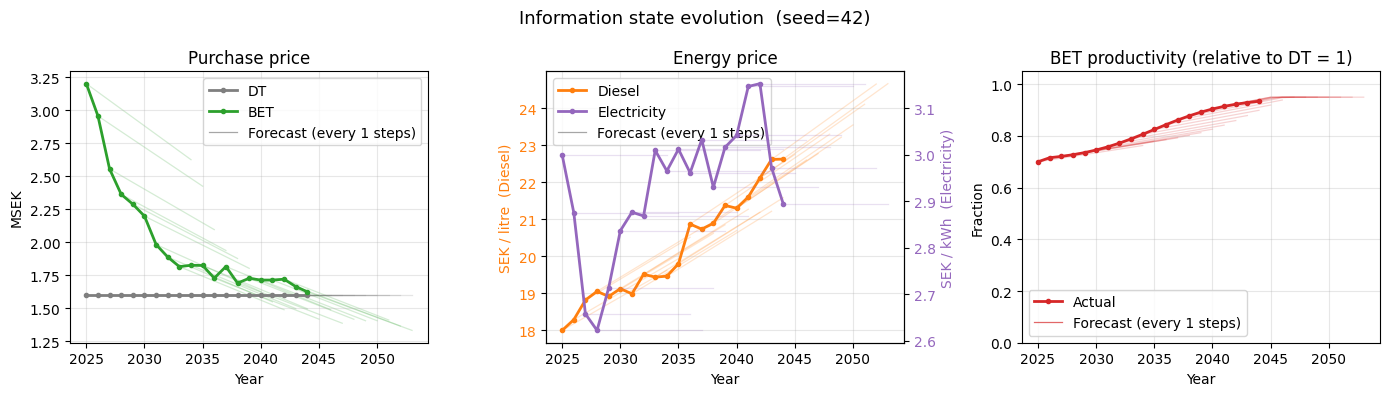

In [4]:
from plot_helpers import plot_episode_information_state

plot_episode_information_state(record, agent)

In [5]:
record.reward_component("sale_result")

array([      0.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        ,  832000.        ,
        832000.        ,  832000.        ,       0.        ,
        832000.        ,  832000.        , 2688000.        ,
        960000.        ,  960000.        ,       0.        ,
             0.        ,       0.        ,  893628.51151727,
        864679.94399501, 2531509.65689788])